TESTING THE CODE

In [1]:
# Run this line if you want to restart the kenerl
from IPython.display import display, Javascript

display(Javascript('IPython.notebook.kernel.restart()'))


<IPython.core.display.Javascript object>

In [1]:
# Check if the gpu is available
import tensorflow as tf
physical_devices_1 = tf.config.list_physical_devices('GPU')
physical_devices_2 = tf.config.list_physical_devices(']CPU')
print(physical_devices_1)
print(physical_devices_2)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[]


In [2]:
import tensorflow as tf
print(tf.__version__)
import numpy as np
import os
from PIL import Image

2.10.0


In [3]:
folder_path = 'IL033_teste_export_slice_tiff/'
# List all files in the folder
files = os.listdir(folder_path)

In [4]:
leng = len(files)-1
#leng = 5
specific_value = leng

In [5]:
leng

3121

In [6]:
# Calculate the variation into the 3121 slices of the tomography image:
# Circle_radius
circle_radius_initial_parameter = 2.351
circle_radius_final_parameter = 2.365
variation_circle_parameter = abs(circle_radius_final_parameter - circle_radius_initial_parameter)
delta_circle_parameter = variation_circle_parameter/3121
#delta_circle_parameter, variation_circle_parameter, delta_circle_parameter * 3121
# calculate the variation into the 3121 width parameter
circle_center_width_initial_parameter = 1.93
circle_center_width_final_parameter = 1.94
variation_center_width_parameter = abs(circle_center_width_final_parameter - circle_center_width_initial_parameter)
delta_center_width_parameter = variation_center_width_parameter/3121
#variation_center_width_parameter, delta_center_width_parameter, delta_center_width_parameter * 3121
# calculate the variation into the 3121 height parameter
circle_center_height_initial_parameter = 1.98
circle_center_height_final_parameter = 2.04
variation_center_height_parameter = abs(circle_center_height_final_parameter - circle_center_height_initial_parameter)
delta_center_height_parameter = variation_center_height_parameter/3121
#variation_center_height_parameter, delta_center_height_parameter, delta_center_height_parameter * 3121

In [7]:
# To check the values until the iteration 700
# Allocate the vector to save the properties to each slice
###Grain_Area_vector_values = np.zeros_like(np.zeros(leng-2421))
###Grain_fraction_vector_values = np.zeros_like(np.zeros(leng-2421))
###porosity_vector_values = np.zeros_like(np.zeros(leng-2421))
###pore_Area_vector_values = np.zeros_like(np.zeros(leng-2421))

In [8]:
# Allocate the vector to save the properties to each slice
Grain_Area_vector_values = np.zeros(leng)
Grain_fraction_vector_values = np.zeros(leng)
porosity_vector_values = np.zeros(leng)
pore_Area_vector_values = np.zeros(leng)
ac_train =  np.zeros(leng)
ac_test = np.zeros(leng)
jaccard_metric_mask_real =  np.zeros(leng)
jaccard_metric_unet_real = np.zeros(leng)

loss_train =  np.zeros(leng)
loss_test = np.zeros(leng)

In [9]:
ac_train.shape, ac_test.shape, loss_train.shape, loss_test.shape

((3121,), (3121,), (3121,), (3121,))

In [10]:
Grain_Area_vector_values.shape, Grain_fraction_vector_values.shape, porosity_vector_values.shape, pore_Area_vector_values.shape

((3121,), (3121,), (3121,), (3121,))

In [11]:
import time

# Start the timer
start_time = time.time()

# Apply the methodology
images = []
import cv2
i = 0
for filename in (files):
    if filename.endswith('.tiff') or filename.endswith('.tif'):
        file_path = os.path.join(folder_path, filename)
        image = cv2.imread(file_path)
        slice_image = np.array(image)
        # Set the grain to be the value 1
        # This function is to create the binary image to the recognition process work
        def create_binary(img):    
            import cv2
            # Convert the image to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Apply a threshold to the grayscale image
            #threshold_value = 95
            threshold_value = img.mean() + 0.24 * img.mean()
            max_value = 1
            # Set the value 1 to be the pore space
            ret, binary = cv2.threshold(gray, threshold_value, max_value, cv2.THRESH_BINARY)
            return binary
        ##def create_binary_otsu(img):    
        ##    import cv2
    
            # Convert the image to grayscale
        ##    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Apply Otsu's thresholding
        ##    ret, binary = cv2.threshold(gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
        ##    return binary
        slice_image_binary = create_binary(slice_image)
        # BEGGIN FUNCTION SEGMENTATION WITH U NET
        # Calling the function
        def segmentation_with_u_net_sample_1(image_array, mask_array):
            # convert the image_array from uint8 to float64
            import numpy as np
            # convert to the numpy array
            image_array = np.array(image_array)
            mask_array = np.array(mask_array)
            # Remove the third dimension
            image_array = image_array[:, :, 0]
            # Convert uint8 to float64
            image_array = image_array.astype('float32')
    
            # convert the image_array from uint8 to float64
            import numpy as np

            # Convert uint8 to float64
            ##mask_array = mask_array.astype('bool')
            # Convert uint8 to float64
            mask_array = mask_array.astype('float32')
            # calculate the range of the min and max value of the image_array
            range_image_array = image_array.max() - image_array.min()
            # normalize the image_array to segmentation task
            image_array = (image_array - image_array.min()) / (range_image_array)
            # The step is the size of the moviment in one direction by the patch.
     
    
            from skimage.util import view_as_windows
            #==================old version to create patches==================
            # create patches to the images (original and binary)
            # Split the image and mask arrays into patches
            ##patch_size = (256, 256)  # define the patch size
            ##image_patches = view_as_windows(image_array, patch_size, step=256) 
            ##mask_patches = view_as_windows(mask_array, patch_size, step=256)

            # Reshape the patches to flatten them into 2D arrays
            ##image_patches = image_patches.reshape(-1, *patch_size)
            ##mask_patches = mask_patches.reshape(-1, *patch_size)
            # Add the color channel to the patches
            # Add a color channel
            ##image_patches = np.expand_dims(image_patches, axis=3)
            ##mask_patches = np.expand_dims(mask_patches, axis=3)
            #================================================================
            #===================new version to creat patches=================
            ## New version - sucess
            ## If you normalize the original image, you need to convert to the original scale to reconstruct
            ## If you don't normalize the code works...
            import numpy as np
            from skimage.util import view_as_windows

            # Convert image_array from uint8 to float64
            ##image_array = np.array(image_array)[:, :, 0].astype('float32')

            # Convert mask_array from uint8 to boolean
            ##mask_array = np.array(mask_array).astype('bool')

            # Normalize the image_array
            #range_image_array = image_array.max() - image_array.min()
            #image_array = (image_array - image_array.min()) / (range_image_array)

            # Split the image and mask arrays into patches
            patch_size = (184, 184)
            step = 184
            image_patches = view_as_windows(image_array, patch_size, step=step)
            mask_patches = view_as_windows(mask_array, patch_size, step=step)

            # Reshape the patches to flatten them into 2D arrays
            image_patches_flat = image_patches.reshape(-1, *patch_size)
            mask_patches_flat = mask_patches.reshape(-1, *patch_size)

            # Add the color channel to the patches
            image_patches_flat = np.expand_dims(image_patches_flat, axis=3)
            mask_patches_flat = np.expand_dims(mask_patches_flat, axis=3)

            # Save the position of each patch
            patch_positions = []

            for i in range(image_patches.shape[0]):
                for j in range(image_patches.shape[1]):
                    start_row = i * step
                    start_col = j * step
                    end_row = start_row + patch_size[0]
                    end_col = start_col + patch_size[1]

                    patch_positions.append({
                        'start_row': start_row,
                        'start_col': start_col,
                        'end_row': end_row,
                        'end_col': end_col
                                })

            # Save the patch positions as a NumPy array
            patch_positions_array = np.array(patch_positions)
    
    
    
    
    
            from sklearn.model_selection import train_test_split
    
            # assume X is your feature matrix and y is your target vector
            X_train, X_test, y_train, y_test = train_test_split(image_patches_flat, mask_patches_flat, test_size=0.2, random_state=42)
            # test_size = 0.3 specifies that 30% of the data will be used for testing
            # random_state = 42 sets a seed for the random number generator to ensure reproducibility
    
#             #import necessary libraries
#             import numpy as np 
#             from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
#             from tensorflow.keras.models import Model
#             from tensorflow.keras.optimizers import Adam

#             #define parameters
#             input_shape = (184, 184, 1)
#             filters = 92
            
        
#             from keras.callbacks import EarlyStopping

#             # Construct model
#             inputs = Input(input_shape)
#             x = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs)
#             x = MaxPooling2D((2, 2), padding='same')(x)
#             x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
#             x = UpSampling2D((2, 2))(x)
#             outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
#             # Change the activation function in the final layer to 'sigmoid'
    

#             # Compile model
#             model = Model(inputs=[inputs], outputs=[outputs])
#             model.compile(optimizer=Adam(lr=0.01), loss='binary_crossentropy', metrics=['accuracy'])

#             # Define EarlyStopping callback
#             early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
#             model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)
#             
            # random_state = 42 sets a seed for the random number generator to ensure reproducibility
            import numpy as np 
            from keras.callbacks import EarlyStopping
            from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
            from tensorflow.keras.models import Model
            from tensorflow.keras.optimizers import Adam
            
    
            # Define parameters
            input_shape = (184, 184, 1)
            filters = 64

            # U-Net model
            def unet(input_shape, filters=32):
                inputs = Input(input_shape)
    
                # Contracting path
                conv1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs)
                conv1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(conv1)
                pool1 = MaxPooling2D((2, 2))(conv1)
    
                conv2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(pool1)
                conv2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(conv2)
                pool2 = MaxPooling2D((2, 2))(conv2)

                # Bottom
                conv3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(pool2)
                conv3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(conv3)

                # Expansive path
                up4 = concatenate([UpSampling2D((2, 2))(conv3), conv2], axis=-1)
                conv4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(up4)
                conv4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(conv4)
    
                up5 = concatenate([UpSampling2D((2, 2))(conv4), conv1], axis=-1)
                conv5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(up5)
                conv5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(conv5)

                outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)  # Sigmoid activation for binary segmentation
    
                model = Model(inputs=[inputs], outputs=[outputs])
                return model

            # Define EarlyStopping callback
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

            # Construct and compile the U-Net model
            model = unet(input_shape=input_shape, filters=filters)
            model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy']) 
            # Train the model
            with tf.device('/GPU:0'):
                model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

            y_pred = model.predict(image_patches_flat)
            # Evaluate the model on the test data
            loss_test, final_accuracy_test = model.evaluate(X_test, y_test)
            # Evaluate the model on the train data
            loss_train, final_accuracy_train = model.evaluate(X_train, y_train)
            ####y_pred = mask_patches_flat # Test
            return y_pred, image_patches_flat, mask_patches_flat, patch_positions_array, final_accuracy_train, final_accuracy_test, loss_train, loss_test
            ####y_pred = mask_patches_flat # Test # the thresold is img.mean() + 0.20 * img.mean()
            #return y_pred, image_patches_flat, mask_patches_flat, patch_positions_array
            # END FUNCTION SEGMENTATION WITH U NET
        y_pred_slice_tensor, image_slice_tensor_patches, mask_slice_tensor_patches, slice_patch_positions, ac_train_value, ac_test_value, loss_train_value, loss_test_value = segmentation_with_u_net_sample_1(slice_image, slice_image_binary)
        # Function to reconstruct the original image and mask
        import numpy as np

        def jaccard_similarity(image, binary_mask):
            # Flatten the images to 1D arrays
            image_flat = image.flatten()
            binary_mask_flat = binary_mask.flatten()

            # Calculate intersection (number of matching pixels)
            intersection = np.sum(np.logical_and(image_flat, binary_mask_flat))

            # Calculate union (number of pixels marked as foreground in either image or mask)
            union = np.sum(np.logical_or(image_flat, binary_mask_flat))

            # Calculate Jaccard similarity coefficient
            jaccard = intersection / union

            return jaccard

        # Example usage:
        # Assuming 'image' and 'binary_mask' are the original image and its binary mask
        image_slice_tensor_patches.shape, y_pred_slice_tensor.shape
        jaccard_metric_unet_real[i] = jaccard_similarity(image_slice_tensor_patches, y_pred_slice_tensor)
        print("Jaccard similarity coefficient with cnn:", jaccard_metric_unet_real[i])
        # Example usage:
        # Assuming 'image' and 'binary_mask' are the original image and its binary mask
        jaccard_metric_mask_real[i] = jaccard_similarity(image_slice_tensor_patches, mask_slice_tensor_patches)
        print("Jaccard similarity coefficient with thresold:", jaccard_metric_mask_real[i])
        def reconstruct_mask(mask_patches_flat, patch_positions_array, image_shape):
            # Get the original image shape
            original_shape = (image_shape[0], image_shape[1])

            # Initialize empty arrays for the reconstructed image and mask
            reconstructed_mask = np.zeros(original_shape, dtype='float32')

            for i, position in enumerate(patch_positions_array):
                start_row, start_col = position['start_row'], position['start_col']
                end_row, end_col = position['end_row'], position['end_col']

                # Extract the patches from the flat arrays
                #image_patch = image_patches_flat[i, :, :, 0]
                mask_patch = mask_patches_flat[i, :, :, 0]

                # Update the reconstructed image and mask
                #reconstructed_image[start_row:end_row, start_col:end_col] = image_patch
                reconstructed_mask[start_row:end_row, start_col:end_col] = mask_patch

            return reconstructed_mask
        # (you can replace these with your actual variables)
        reconstructed_mask_slice_image_tensor = reconstruct_mask(y_pred_slice_tensor, slice_patch_positions, slice_image.shape)
        print(reconstructed_mask_slice_image_tensor.min(), reconstructed_mask_slice_image_tensor.max())
        
        # When you set the grain to be the value 1 # background 
        # You are suppose to use the calculate_pore_properties_gray_version_rock to calculate the properties
        import numpy as np

        def calculate_pore_properties_gray_version_rock(segmented_image, pixel_area, circle_area):
            """
            Calculate pore properties including pore area and porosity for a grayscale segmented image.

            Parameters:
            - segmented_image: 2D segmented image where pores are represented by values between 0 and 1.
            - pixel_area: Area of a single pixel in the image.

            Returns:
            - grain_area: Total area of segmented grain regions.
            - fraction_matrix: matrix calculated as the ratio of grain area to the total area.
            """
            # Check if the input image is within the valid range
            if not (np.all(0 <= segmented_image) and np.all(segmented_image <= 1)):
                raise ValueError("Input image must have values between 0 and 1 for grayscale segmentation.")
            # Calculate pore area
            grain_area = np.sum(segmented_image) * pixel_area
    
            # Calculate total area of the image
            #total_area = np.sum(segmented_image >= 0) * pixel_area
            ##total_area = np.sum(segmented_image >= segmented_image.min()) * pixel_area
            total_area = circle_area
            # Calculate porosity
            fraction_matrix = grain_area / total_area
            porosity = 1.0 - fraction_matrix
            pore_area = total_area - grain_area
            return grain_area, fraction_matrix, porosity, pore_area
        
        import random

        import numpy as np
        import cv2

        # Define the range
        #min_value = 1
        #max_value = 3121

        # Generate a random number between the range
        #random_number = random.randint(min_value, max_value)

        # Print the random number
        #print(random_number)

        # Assuming you have loaded the image
        #image = globals()[f'tensor_image_{random_number}']  # Placeholder for the image, replace with your image loading code
        ##image = slice_image # the same thing of the code bellow, you avoid to spent the memory.
        # Get the dimensions of the image
        height, width, _ = slice_image.shape

        # Assuming you have defined these variables elsewhere in your code
        ##delta_circle_parameter = 0.5
        ##delta_center_width_parameter = 0.3
        ##delta_center_height_parameter = 0.2
        
        
        # Calculate the radius and center of the circle (with float coordinates)
        circle_radius = min(width, height) / (2.351 + ((i) * delta_circle_parameter))  # Adjust the radius as needed with a float value
        circle_center = (width / (1.93 + ((i) * delta_center_width_parameter)), height / (1.98 + ((i) * delta_center_height_parameter)))

        # Calculate the area of the circle
        circle_area = np.pi * circle_radius ** 2

        # Calculate the external area (total area - circle area)
        external_area = height * width - circle_area

        # Print the calculated areas
        ##print("Circle Area:", circle_area)
        ##print("External Area:", external_area)

        # Check if the sum of internal and external areas equals the total area
        total_area = height * width
        sum_of_areas = circle_area + external_area
        ##print("Sum of Areas (Internal + External):", sum_of_areas)
        ##print("Total Area:", total_area)
        ##print("Are the areas equal?", np.isclose(sum_of_areas, total_area))
        # Based on the real size of the object in the world
        # In the real world we have 1704 pixels in a diameter with 3.81 cm
        value_pixel_real_world=(3.81)/(1704) # Simple rule
        # Calculating the distance of the width and height in mm
        image_width_cm = (2024 * value_pixel_real_world)
        image_height_cm = (2024 * value_pixel_real_world)
        image_width_m = image_width_cm * (10)**(-2)
        image_height_m = image_height_cm * (10)**(-2)
        # Calculating the total area in meters:
        total_check_real_area = (image_width_m) * (image_height_m)
        # Calculate the total number of pixels in the image
        total_pixels_horizontal = 2024
        total_pixels_vertical = 2024
        total_pixels = total_pixels_horizontal * total_pixels_vertical

        # Calculate the area represented by each pixel in the real world
        pixel_area_real_world = (image_width_m * image_height_m) / total_pixels
        # Atribute the area to each pixel in the real world
        pixel_area = pixel_area_real_world
        # Define the circle area and the external area.
        circle_area_real = circle_area * pixel_area
        external_area_real = external_area * pixel_area
        # Shave the properties in each vector
        ac_train[i], ac_test[i], loss_train[i], loss_test[i] = ac_train_value, ac_test_value, loss_train_value, loss_test_value
        Grain_Area_vector_values[i], Grain_fraction_vector_values[i], porosity_vector_values[i], pore_Area_vector_values[i] = calculate_pore_properties_gray_version_rock(reconstructed_mask_slice_image_tensor, pixel_area, circle_area_real)
        globals()[f'name_slice_{i}'] = filename
        print('The iteration:',i, 'is complete')
        i = i + 1
        if i == specific_value:
            print("Found the specific value. Stopping the loop.")
            break  # Exit the loop

# End the timer
end_time = time.time()

# Calculate the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Convert elapsed time from seconds to hours
elapsed_time_hours = elapsed_time_seconds / 3600

print("Time elapsed:", elapsed_time_hours, "hours")

Epoch 1/20
3/3 [==============================] - 35s 2s/step - loss: 0.6536 - accuracy: 0.4804 - val_loss: 0.6289 - val_accuracy: 0.6100
Epoch 2/20
3/3 [==============================] - 1s 360ms/step - loss: 0.6057 - accuracy: 0.6817 - val_loss: 0.5492 - val_accuracy: 0.6567
Epoch 3/20
3/3 [==============================] - 1s 348ms/step - loss: 0.5283 - accuracy: 0.7926 - val_loss: 0.5548 - val_accuracy: 0.9388
Epoch 4/20
3/3 [==============================] - 1s 353ms/step - loss: 0.4762 - accuracy: 0.9204 - val_loss: 0.3576 - val_accuracy: 0.9234
Epoch 5/20
3/3 [==============================] - 1s 353ms/step - loss: 0.4655 - accuracy: 0.7950 - val_loss: 0.1982 - val_accuracy: 0.9295
Epoch 6/20
3/3 [==============================] - 1s 348ms/step - loss: 0.3154 - accuracy: 0.9117 - val_loss: 0.2106 - val_accuracy: 0.9185
Epoch 7/20
3/3 [==============================] - 1s 348ms/step - loss: 0.2317 - accuracy: 0.9114 - val_loss: 0.2395 - val_accuracy: 0.9324
Epoch 8/20
3/3 [======

In [13]:
ac_train[0], ac_test[0], loss_train[0], loss_test[0]

(0.9275722503662109,
 0.9349172711372375,
 0.15655457973480225,
 0.14113177359104156)

In [14]:
# Calcular os minutos a partir da parte decimal do tempo decorrido em horas
elapsed_minutes = (elapsed_time_hours - int(elapsed_time_hours)) * 60

print("Time elapsed:", int(elapsed_time_hours), "hours and", round(elapsed_minutes), "minutes")


Time elapsed: 19 hours and 16 minutes


In [15]:
# Calcular os minutos a partir da parte decimal do tempo decorrido em horas
elapsed_minutes = (elapsed_time_hours - int(elapsed_time_hours)) * 60

print("Time elapsed:", int(elapsed_time_hours), "hours and", round(elapsed_minutes), "minutes")


Time elapsed: 18 hours and 26 minutes


In [15]:
porosity_vector_values.min()


-0.7260637801724772

In [17]:
porosity_vector_values[0]

0.12575752039985477

In [18]:
porosity_vector_values[3120]

0.11759586414328216

In [19]:
len(porosity_vector_values)

3121

In [20]:
porosity_vector_values.min(), porosity_vector_values.max()

(-0.6991148267839886, 0.9980206319003518)

In [21]:
# Calculating the distance between the pixels in each direction:
# In the real world we have 1704 pixels in a diameter with 3.81 cm
value_pixel_real_world=(3.81)/(1704) # Simple rule
# Calculating the distance of the width and height in mm
image_width_cm = (2024 * value_pixel_real_world)
image_height_cm = (2024 * value_pixel_real_world)
image_width_m = image_width_cm * (10)**(-2)
image_height_m = image_height_cm * (10)**(-2)
# Calculating the total area in meters:
total_check_real_area = (image_width_m) * (image_height_m)
# Calculate the total number of pixels in the image
total_pixels_horizontal = 2024
total_pixels_vertical = 2024
total_pixels = total_pixels_horizontal * total_pixels_vertical

In [22]:
image_width_m, image_height_m

(0.045254929577464784, 0.045254929577464784)

In [23]:
# Define the dimensions of the image in meters
image_width_meters = image_width_m  # example width of the image in meters
image_height_meters = image_height_m  # example height of the image in meters

# Calculate the number of pixels in each direction
number_of_pixels_in_each_direction = total_pixels_horizontal  # Assuming y_pred is your prediction array

# Calculate the distance between pixels in meters
pixel_distance_horizontal = image_width_meters / (number_of_pixels_in_each_direction - 1)
pixel_distance_vertical = image_height_meters / (number_of_pixels_in_each_direction - 1)

# Calculate the total area
total_area = image_width_meters * image_height_meters

# Print the results
print("Distance between pixels horizontally:", pixel_distance_horizontal, "meters")
print("Distance between pixels vertically:", pixel_distance_vertical, "meters")
print("Total Area:", total_area, "square meters")

Distance between pixels horizontally: 2.2370207403591095e-05 meters
Distance between pixels vertically: 2.2370207403591095e-05 meters
Total Area: 0.002048008651061297 square meters


In [24]:
# Checking if the area formed by the distance between the pixels is less than the total area.
pixel_distance_horizontal * pixel_distance_vertical  < total_area

True

In [25]:
# There are two ways to define the dz to the riemann integral:
# The first way
# comp_z = number_of_crooped_images * mean of the distance between pixels
length_z = 7.36*10**(-2)


# Checking the dz
dz1 = length_z/3121.

dz2 = value_pixel_real_world+pixel_distance_horizontal
dz1, dz2
# A razão de aspecto do pixel é 1, então o diametro é de uma esfera.
# dz1 - intervalo do slice baseado nos intervalos entre os slices no valor real.
# dz2 - intervalo do slice baseado no diametro do pixel na transformação de escala para o real.

(2.3582185197052225e-05, 0.0022582857003613376)

## Calculating the 3d properties by using the riemann integral

In [26]:
porosity_vector_values.min(), porosity_vector_values.max()

(-0.6991148267839886, 0.9980206319003518)

In [27]:
porosity_vector_values[2201], porosity_vector_values[3120]

(0.23683185087058678, 0.11759586414328216)

In [28]:
porosity_vector_values[2200], Grain_fraction_vector_values[2200]

(0.12626164454341593, 0.8737383554565841)

In [29]:
def riemann_integral_L_porosity(porosity_values, slice_thickness):
    total_porosity = sum(porosity_values)
    integral_approximation = total_porosity * slice_thickness 
    return integral_approximation

In [30]:
def riemann_integral_L_fraction_grain(fraction_grain_values, slice_thickness):
    total_fraction_grain = sum(fraction_grain_values) 
    integral_approximation = total_fraction_grain * slice_thickness 
    return integral_approximation

In [31]:
def riemann_integral_L_pore_area(pore_area_values, slice_thickness):
    total_pore_area = sum(pore_area_values)
    integral_approximation = total_pore_area * slice_thickness
    return integral_approximation

In [32]:
def riemann_integral_L_grain_area(grain_area_values, slice_thickness):
    total_grain_area = sum(grain_area_values)
    integral_approximation = total_grain_area * slice_thickness
    return integral_approximation

In [33]:
## side Area of  cylinder
r = value_pixel_real_world/2
side_area = 2 * 3.1415 * r * length_z

In [34]:
delta_side_area = side_area/3121
delta_side_area_percentage = (delta_side_area * 100.0) / side_area
delta_side_area, side_area, delta_side_area_percentage


(1.6564429963310786e-07, 0.0005169758591549296, 0.03204101249599488)

In [35]:
# In the case of porosity and grain fraction, the integral is supposed to be in percentage, wich means that
# we need to covnert the interval "H" and the range of riemman integral both in percentage

# Example porosity values (vector representing porosity values at discrete depths)
# Example porosity values at different }depths
# The "H" of the reimann integral

slice_thickness =  dz1 # meters 

##Slice_thickness = pixel_distance_horizontal * (10**(-2))
##slice_thickness_percentage = (100.0 * slice_thickness)/(length_z) # based on the length
slice_thickness_percentage = delta_side_area_percentage # Based on the side area

# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_porosity = riemann_integral_L_porosity(porosity_vector_values, slice_thickness_percentage)

print("Riemann integral approximation for porosity in 3D to the sample IL033:", integral_approximation_porosity, "%")

Riemann integral approximation for porosity in 3D to the sample IL033: 13.621644105785384 %


In [36]:
porosity_vector_values.min(), porosity_vector_values.max()

(-0.6991148267839886, 0.9980206319003518)

In [37]:
porosity_vector_values[0]

0.12575752039985477

In [38]:
import numpy as np

# Assuming porosity_vector_values is a NumPy array
# Find the minimum value and its index
min_value = np.min(porosity_vector_values)
min_position = np.argmin(porosity_vector_values)

print("Minimum value:", min_value)
print("Position of minimum value:", min_position)


Minimum value: -0.6991148267839886
Position of minimum value: 699


In [39]:
import numpy as np

# Assuming porosity_vector_values is a NumPy array
# Find the minimum value and its index
max_value = np.max(porosity_vector_values)
max_position = np.argmax(porosity_vector_values)

print("Maximun value:", max_value)
print("Position of Maximun value:", max_position)

Maximun value: 0.9980206319003518
Position of Maximun value: 695


In [40]:
slice_number = max_position+330-1
slice_number

1024

In [41]:
slice_thickness_percentage

0.03204101249599488

In [42]:
# The "H" of the reimann integral
##slice_thickness = (pixel_distance_horizontal + pixel_distance_vertical) / 2  # meters 

# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_grain_fraction = riemann_integral_L_fraction_grain(Grain_fraction_vector_values, slice_thickness_percentage)

print("Riemann integral approximation for grain fraction in 3D over length:", integral_approximation_grain_fraction, "%")

Riemann integral approximation for grain fraction in 3D over length: 86.37835589421464 %


In [43]:
integral_approximation_porosity + integral_approximation_grain_fraction

100.00000000000001

In [44]:
# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_pore_volume = riemann_integral_L_pore_area(pore_Area_vector_values, slice_thickness)

print("Riemann integral approximation for pore_volume:", integral_approximation_pore_volume,"m^3")

Riemann integral approximation for pore_volume: 1.1602535531681002e-05 m^3


In [45]:
pore_Area_vector_values[1], Grain_Area_vector_values[1]

(0.00017061096415809957, 0.0009934473685079223)

In [46]:
# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_grain_volume = riemann_integral_L_grain_area(Grain_Area_vector_values, slice_thickness)

print("Riemann integral approximation for grain_volume:", integral_approximation_grain_volume, "m^3")

Riemann integral approximation for grain_volume: 7.356547957187051e-05 m^3


In [3]:
length_z = 7.36*10

In [4]:
vol_sample = 3.1415 * ((3.81/2)*10**(-2))**2 * length_z # in meters cubic

In [5]:
vol_sample

0.08390828379600002

In [1]:
total_volu = integral_approximation_pore_volume + integral_approximation_grain_volume
print('Checando o volume total da amostra (aproximado)',total_volu, vol_sample)


NameError: name 'integral_approximation_pore_volume' is not defined

In [ ]:
percentual_variation = ((total_volu - vol_sample)*100.0)/vol_sample

In [50]:
# priting the error
print('the error in relation to the volume of the sample is:',percentual_variation,'%')


the error in relation to the volume of the sample is: 1.5013193579482453 %


In [51]:
## Calculating the porosity from the volume grain and pore:
#total_volu
#integral_approximation_grain_volume
grain_frac = (integral_approximation_grain_volume * 100)/total_volu
grain_frac

86.37688630224145

### Graphic of the 2d variation properties

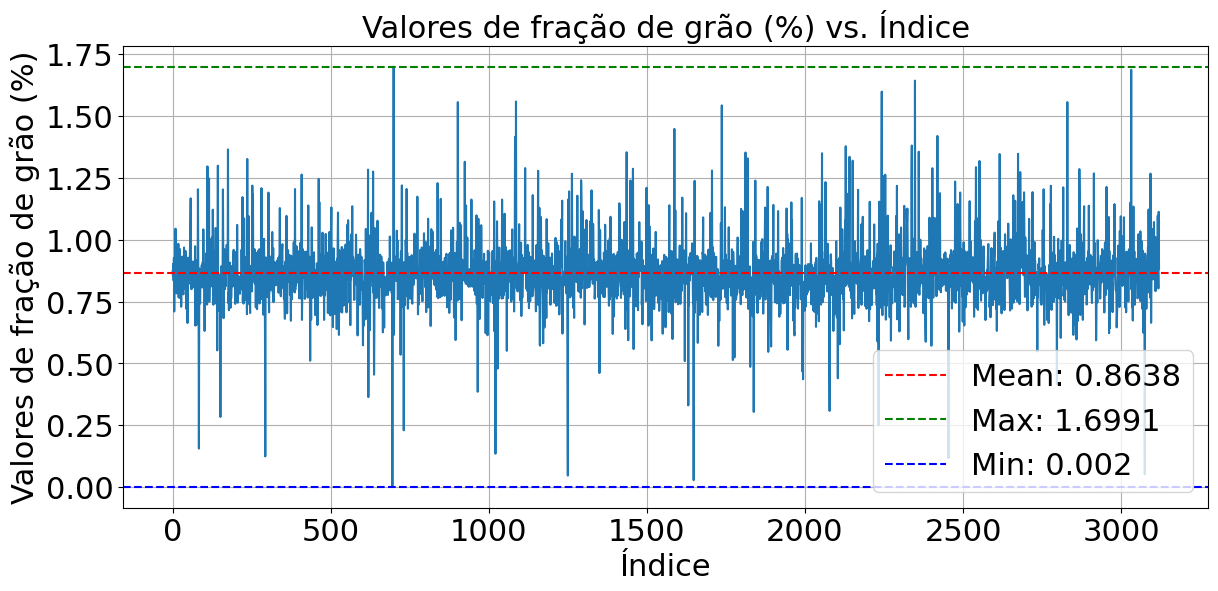

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# Ajustar o tamanho da figura
plt.figure(figsize=(18, 6))  # Largura = 18 polegadas, Altura = 6 polegadas

# Plot
plt.plot(np.arange(len(Grain_fraction_vector_values)), abs(Grain_fraction_vector_values))
plt.xlabel('Índice', fontsize=22)
plt.ylabel('Valores de fração de grão (%)', fontsize=22)
plt.title('Valores de fração de grão (%) vs. Índice', fontsize=22)

# Calculate statistics
mean_value = Grain_fraction_vector_values.mean()
max_value = Grain_fraction_vector_values.max()
min_value = Grain_fraction_vector_values.min()

# Round the statistics to four decimal places
mean_value = round(mean_value, 4)
max_value = round(max_value, 4)
min_value = round(min_value, 4)


# Draw lines for mean, max, and min
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value}')
plt.axhline(y=max_value, color='g', linestyle='--', label=f'Max: {max_value}')
plt.axhline(y=min_value, color='b', linestyle='--', label=f'Min: {min_value}')
plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)

# Save the plot as PNG
plt.savefig('TheCNN_unet_results\Grain_fraction_unet_plot.png')

plt.show()



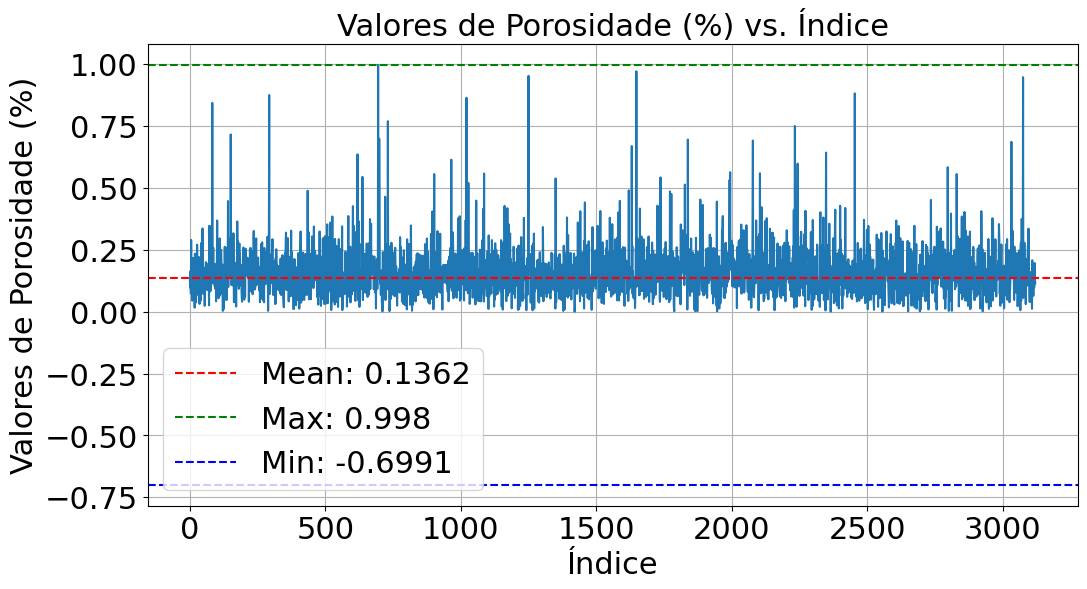

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Ajustar o tamanho da figura
plt.figure(figsize=(12, 6))  # Largura = 18 polegadas, Altura = 6 polegadas

# Plot
plt.plot(np.arange(len(porosity_vector_values)), abs(porosity_vector_values))
plt.xlabel('Índice', fontsize=22)
plt.ylabel('Valores de Porosidade (%)', fontsize=22)
plt.title('Valores de Porosidade (%) vs. Índice', fontsize=22)

# Calculate statistics
mean_value = porosity_vector_values.mean()
max_value = porosity_vector_values.max()
min_value = porosity_vector_values.min()

# Round the statistics to four decimal places
mean_value = round(mean_value, 4)
max_value = round(max_value, 4)
min_value = round(min_value, 4)

# Draw lines for mean, max, and min
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value}')
plt.axhline(y=max_value, color='g', linestyle='--', label=f'Max: {max_value}')
plt.axhline(y=min_value, color='b', linestyle='--', label=f'Min: {min_value}')

plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)

# Save the plot as PNG
plt.savefig('TheCNN_unet_results\porosity_unet_plot.png')

plt.show()

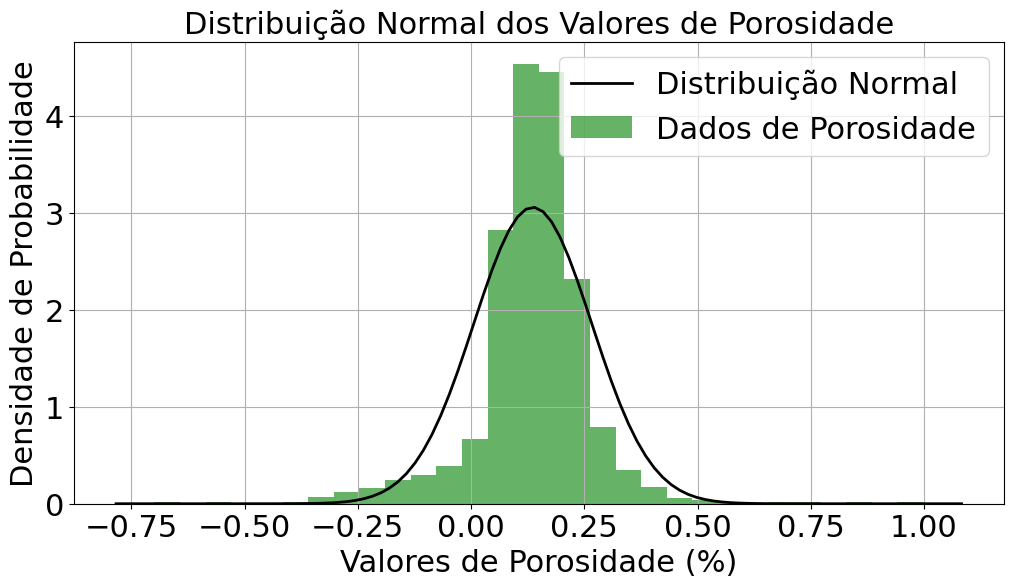

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Dados de exemplo (valores de porosidade)
# porosity_vector_values = np.random.normal(loc=mean_value, scale=std_value, size=1000)

# Ajustar o tamanho da figura
plt.figure(figsize=(12, 6))

# Plot da distribuição normal
plt.hist(porosity_vector_values, bins=30, density=True, alpha=0.6, color='g')

# Obter os parâmetros da distribuição normal
mu, std = norm.fit(porosity_vector_values)

# Calcular a PDF da distribuição normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot da PDF da distribuição normal
plt.plot(x, p, 'k', linewidth=2)

# Adicionar legendas e rótulos
plt.title('Distribuição Normal dos Valores de Porosidade', fontsize=22)
plt.xlabel('Valores de Porosidade (%)', fontsize=22)
plt.ylabel('Densidade de Probabilidade', fontsize=22)
plt.legend(['Distribuição Normal', 'Dados de Porosidade'], fontsize=22)

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)

# Salvar o gráfico como PNG
plt.savefig('TheCNN_unet_results\porosity_distribution_plot_unet.png')

plt.show()


In [61]:
pore_Area_vector_values.shape

(3121,)

In [62]:
pore_Area_vector_values_cm_2 = pore_Area_vector_values*(10)**(4)

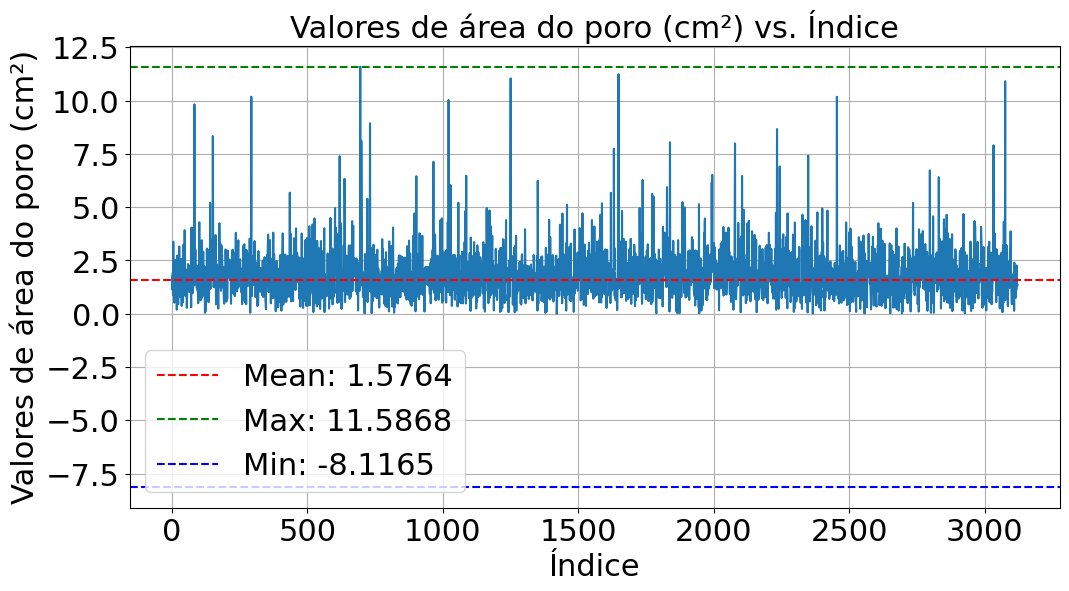

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Ajustar o tamanho da figura
plt.figure(figsize=(12, 6))  # Largura = 18 polegadas, Altura = 6 polegadas

# Plot
plt.plot(np.arange(len(pore_Area_vector_values_cm_2)), abs(pore_Area_vector_values_cm_2))
plt.xlabel('Índice', fontsize=22)
plt.ylabel('Valores de área do poro (cm²)', fontsize=22)
plt.title('Valores de área do poro (cm²) vs. Índice', fontsize=22)

# Calculate statistics
mean_value = pore_Area_vector_values_cm_2.mean()
max_value = pore_Area_vector_values_cm_2.max()
min_value = pore_Area_vector_values_cm_2.min()

# Round the statistics to four decimal places
mean_value = round(mean_value, 4)
max_value = round(max_value, 4)
min_value = round(min_value, 4)


# Draw lines for mean, max, and min
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value}')
plt.axhline(y=max_value, color='g', linestyle='--', label=f'Max: {max_value}')
plt.axhline(y=min_value, color='b', linestyle='--', label=f'Min: {min_value}')

plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)

# Save the plot as PNG
plt.savefig('TheCNN_unet_results\pore_area_unet_plot.png')

plt.show()

In [64]:
Grain_Area_vector_values.shape

(3121,)

In [65]:
Grain_Area_vector_values_cm_2 = Grain_Area_vector_values * 10**(4)

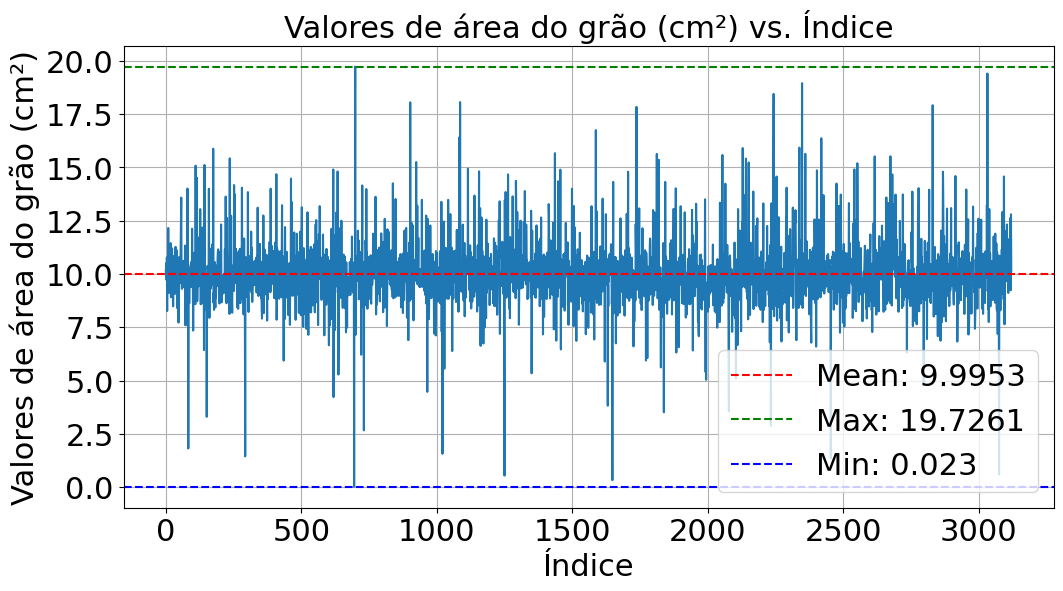

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Ajustar o tamanho da figura
plt.figure(figsize=(12, 6))  # Largura = 18 polegadas, Altura = 6 polegadas

# Plot
plt.plot(np.arange(len(Grain_Area_vector_values_cm_2)), abs(Grain_Area_vector_values_cm_2))
plt.xlabel('Índice', fontsize=22)
plt.ylabel('Valores de área do grão (cm²)', fontsize=22)
plt.title('Valores de área do grão (cm²) vs. Índice', fontsize=22)

# Calculate statistics
mean_value = Grain_Area_vector_values_cm_2.mean()
max_value = Grain_Area_vector_values_cm_2.max()
min_value = Grain_Area_vector_values_cm_2.min()

# Round the statistics to four decimal places
mean_value = round(mean_value, 4)
max_value = round(max_value, 4)
min_value = round(min_value, 4)

# Draw lines for mean, max, and min
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value}')
plt.axhline(y=max_value, color='g', linestyle='--', label=f'Max: {max_value}')
plt.axhline(y=min_value, color='b', linestyle='--', label=f'Min: {min_value}')

plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)

# Save the plot as PNG
plt.savefig('TheCNN_unet_results\grain_area_unet_plot.png')

plt.show()

In [68]:
porosity_vector_values.min(), porosity_vector_values.max()

(-0.6991148267839886, 0.9980206319003518)

In [69]:
Grain_fraction_vector_values.min(), Grain_fraction_vector_values.max()

(0.001979368099648116, 1.6991148267839886)

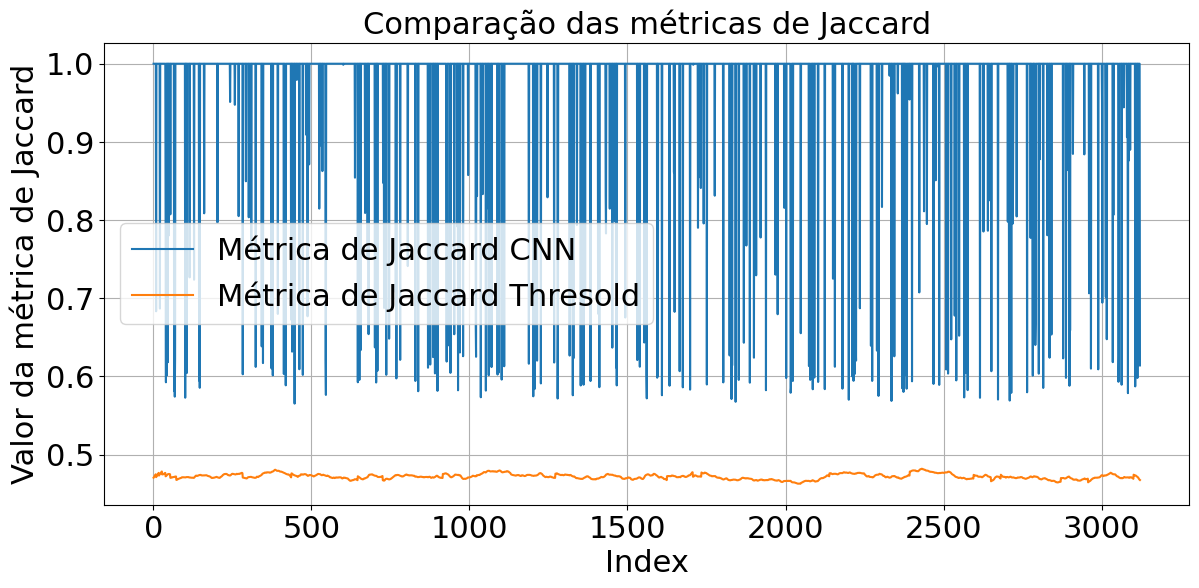

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of numbers from 1 to the length of the vectors
num_points = range(1, len(jaccard_metric_unet_real) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(num_points, jaccard_metric_unet_real, label='Métrica de Jaccard CNN')
plt.plot(num_points, jaccard_metric_mask_real, label='Métrica de Jaccard Thresold')
plt.xlabel('Index', fontsize=22)
plt.ylabel('Valor da métrica de Jaccard', fontsize=22)
plt.title('Comparação das métricas de Jaccard', fontsize=22)

plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y
plt.grid(True)
# Save the plot as PNG
plt.savefig('TheCNN_unet_results\Jaccard_metric_unet_vs_thresold_plot.png')
plt.show()

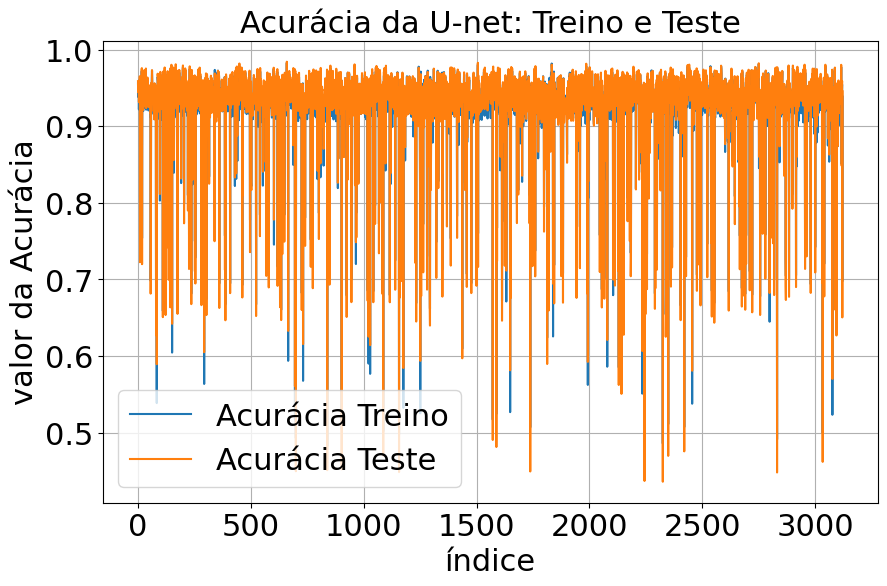

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of numbers from 1 to the length of the vectors
num_points = range(1, len(jaccard_metric_unet_real) + 1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(num_points, ac_train, label='Acurácia Treino')
plt.plot(num_points, ac_test, label='Acurácia Teste')
plt.xlabel('índice', fontsize=22)
plt.ylabel('valor da Acurácia', fontsize=22)
plt.title('Acurácia da U-net: Treino e Teste', fontsize=22)


plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y

plt.grid(True)
plt.savefig('TheCNN_unet_results\c_metric_unet_train_and_test_plot.png')
plt.show()

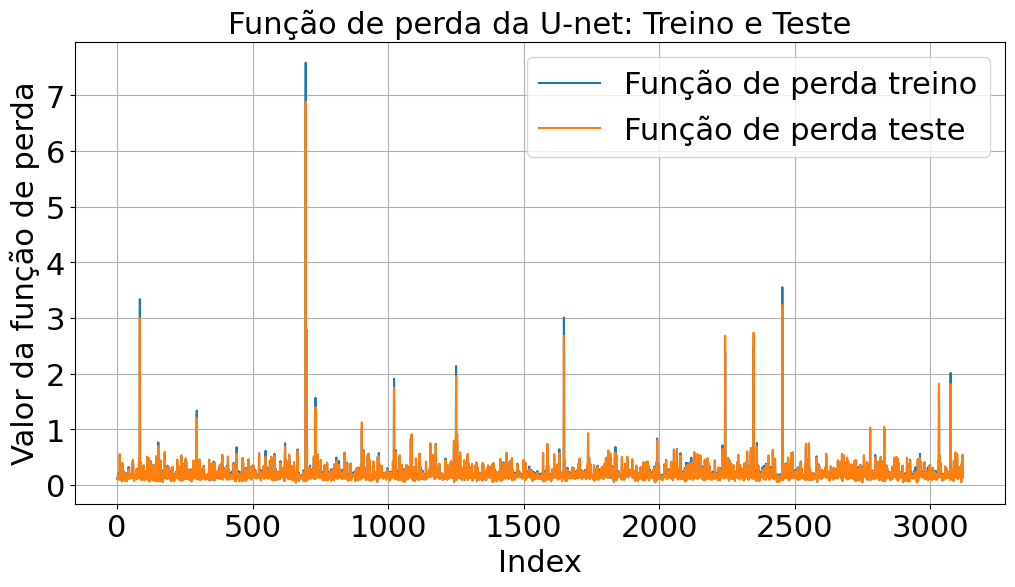

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of numbers from 1 to the length of the vectors
num_points = range(1, len(jaccard_metric_unet_real) + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(num_points, loss_train, label='Função de perda treino')
plt.plot(num_points, loss_test, label='Função de perda teste')
plt.xlabel('Index', fontsize=22)
plt.ylabel('Valor da função de perda', fontsize=22)
plt.title('Função de perda da U-net: Treino e Teste', fontsize=22)

plt.legend(fontsize=22)  # Define o tamanho da fonte para a legenda

plt.xticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo x
plt.yticks(fontsize=22)  # Define o tamanho da fonte para os números no eixo y


plt.grid(True)
plt.savefig('TheCNN_unet_results\loss_metric_unet_train_and_test_plot.png')
plt.show()

In [184]:
value_pixel_real_world*10**(-2)

2.2359154929577465e-05

In [ ]:
# Calculating the distance of the width and height in mm
image_width_cm = (2024 * value_pixel_real_world)
image_height_cm = (2024 * value_pixel_real_world)
image_width_m = image_width_cm * (10)**(-2)
image_height_m = image_height_cm * (10)**(-2)
# Calculating the total area in meters:
total_check_real_area = (image_width_m) * (image_height_m)
# Calculate the total number of pixels in the image
total_pixels_horizontal = 2024
total_pixels_vertical = 2024
total_pixels = total_pixels_horizontal * total_pixels_vertical

# Calculate the area represented by each pixel in the real world
pixel_area_real_world = (image_width_m * image_height_m) / total_pixels
# Atribute the area to each pixel in the real world
pixel_area = pixel_area_real_world
# Define the circle area and the external area.
circle_area_real = circle_area * pixel_area
external_area_real = external_area * pixel_area
# Shave the properties in each vector

In [186]:
pixel_area_real_world, 3.1415*((value_pixel_real_world*(10**(-2)))/2)**2

(4.999318091648481e-10, 3.926339446228428e-10)

In [178]:
value_pixel_real_world=(3.81)/(1704)
value_pixel_real_world

0.0022359154929577464

In [99]:
## Testing
import statistics
# Calculate median
median_value = statistics.median(pore_Area_vector_values)
total_area = sum(pore_Area_vector_values)

# convert to the percentage
median_percentage = (100.0 * median_value)/(total_area)
print("Median:", median_value, 'total area', total_area, 'median percentage', median_percentage)

Median: 7.93011359941885e-05 total area 0.25603352437951415 median percentage 0.030972950197194402


In [100]:
#delta_a = 3.81/3121
delta_a = median_value # The median of area per slice
delta_a_percentage = median_percentage
delta_a, delta_a_percentage


(7.93011359941885e-05, 0.030972950197194402)

In [185]:
def riemann_integral_volume_new_version(porosity_values, delta_h, delta_a):
    total_volume = 0
    for porosity in porosity_values:
        area = porosity * delta_h  # Area of each slice
        volume = area * delta_a  # Volume of each slice
        total_volume += volume  # Accumulate the volume
    return total_volume

In [228]:
# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_porosity_new = riemann_integral_volume_new_version(porosity_vector_values, slice_thickness_percentage, delta_a_percentage)

print("Riemann integral approximation for porosity in 3D to the sample IL033:", integral_approximation_porosity_new, "%")

Riemann integral approximation for porosity in 3D to the sample IL033: 0.21956087311109937 %


In [187]:
## Testing
import statistics
# Calculate median
median_value_grain = statistics.median(Grain_Area_vector_values)
total_area_grain = sum(Grain_Area_vector_values)

# convert to the percentage
median_percentage_grain = (100.0 * median_value_grain)/(total_area_grain)
print("Median:", median_value_grain, 'total area', total_area_grain, 'median percentage', median_percentage_grain)

Median: 0.0010779967109545473 total area 3.355506898693627 median percentage 0.032126195639002715


In [108]:
# The "H" of the reimann integral
##slice_thickness = (pixel_distance_horizontal + pixel_distance_vertical) / 2  # meters 

# Compute Riemann integral approximation for porosity over the depth of the rock
integral_approximation_grain_fraction = riemann_integral_volume_new_version(Grain_fraction_vector_values, slice_thickness_percentage, median_percentage_grain)

print("Riemann integral approximation for grain fraction in 3D over length:", integral_approximation_grain_fraction, "%")

Riemann integral approximation for grain fraction in 3D over length: 2.976969102542287 %
